В данной работе используется датасет, моделирующий сетевое поведение IoT-устройств в домашней Wi-Fi сети. Датасет предназначен для исследования методов машинного обучения для обнаружения потенциальных угроз безопасности и классификации сетевых паттернов устройств.

Каждая запись в датасете представляет собой агрегированную характеристику сетевой активности IoT-устройства за определённый временной интервал. Набор признаков отражает параметры сетевого трафика, такие как интенсивность соединений, характеристики пакетов, распределение IP-адресов назначения и частота DNS-запросов.

Датасет содержит как нормальное поведение устройств, так и различные типы атак, характерных для IoT-сетей. Классификация выполняется по метке label, которая определяет тип сетевой активности.

Классы активности

В датасете представлены следующие классы:

benign — нормальное поведение IoT-устройства без признаков вредоносной активности.

port_scan — сканирование портов, при котором устройство пытается обнаружить открытые сервисы на других узлах сети.

exfil — утечка данных (data exfiltration), характеризующаяся передачей большого объёма информации на внешние серверы.

ddos — атака типа Distributed Denial of Service, при которой устройство генерирует большое количество запросов для перегрузки сервиса.

botnet — устройство является частью ботнета и выполняет команды управляющего сервера.

Признаки датасета

В датасете используются следующие признаки:

device_type — тип IoT-устройства (например, камера, умная розетка, ассистент).

conn_rate_per_min — количество сетевых соединений в минуту.

avg_pkt_size — средний размер сетевого пакета.

pkt_size_std — стандартное отклонение размера пакетов.

bytes_sent_ratio — доля отправленных данных относительно общего объёма трафика.

dst_ip_entropy — энтропия IP-адресов назначения, отражающая разнообразие подключений.

tls_ratio — доля защищённых TLS-соединений.

unique_ports — количество уникальных портов, используемых устройством.

dns_qps — частота DNS-запросов в секунду.

failed_conn_rate — доля неудачных попыток соединения.

avg_interval_s — средний интервал между соединениями.

Цель анализа

Целью данной работы является построение модели машинного обучения, способной по сетевым характеристикам IoT-устройства определить тип сетевой активности и выявить потенциальные угрозы безопасности.

In [ ]:
import pandas as pd

df = pd.read_csv("iot_security_dataset.csv")

df.head()

,device_type,conn_rate_per_min,avg_pkt_size,pkt_size_std,bytes_sent_ratio,dst_ip_entropy,tls_ratio,unique_ports,dns_qps,failed_conn_rate,avg_interval_s,label
0,camera,15.840064,1050.090239,237.622589,0.504896,0.104673,0.612784,2,0.099160,0.005735,3.791458,benign
1,smart_light,0.577779,121.980921,36.763447,0.126751,0.000000,0.886875,1,0.002879,0.000975,113.344955,benign
2,smart_light,0.622254,115.364116,27.430033,0.044787,0.099846,0.886544,1,0.002431,0.002071,105.369059,benign
3,thermostat,1.795103,159.311364,56.159794,0.312897,0.082908,0.815984,1,0.013254,0.006858,34.888388,benign
4,smart_light,0.523216,123.500574,31.312132,0.167143,0.053539,0.917891,1,0.002289,0.001316,67.542390,benign


In [10]:
X = df.drop("label", axis=1)
y = df["label"]

X = pd.get_dummies(X)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Для классификации сетевых паттернов IoT-устройств был выбран алгоритм Random Forest. Данный алгоритм представляет собой ансамбль деревьев решений, обученных на случайных подвыборках данных. Итоговое предсказание формируется на основе голосования деревьев.
Random Forest хорошо подходит для анализа сетевого трафика, поскольку способен выявлять нелинейные зависимости между признаками и устойчив к шуму в данных.

In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      benign       0.98      1.00      0.99       600
      botnet       1.00      0.99      1.00       120
        ddos       1.00      1.00      1.00       120
       exfil       1.00      0.93      0.96       120
   port_scan       1.00      1.00      1.00       120

    accuracy                           0.99      1080
   macro avg       1.00      0.98      0.99      1080
weighted avg       0.99      0.99      0.99      1080



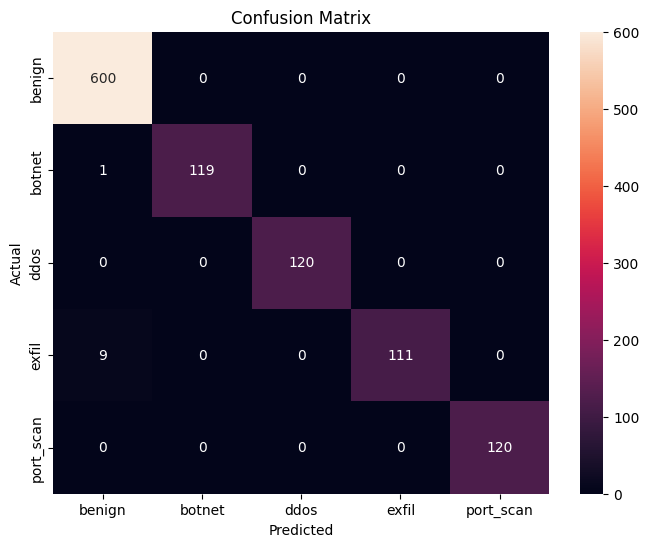

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

В рамках данной работы был разработан модуль классификации сетевых паттернов IoT-устройств для обнаружения потенциальных угроз безопасности в домашней Wi-Fi сети. Для проведения эксперимента использовался синтетический датасет, моделирующий сетевое поведение различных IoT-устройств и несколько типов атак.

На этапе предварительной обработки данные были подготовлены для обучения модели машинного обучения: категориальные признаки были закодированы, после чего датасет был разделён на обучающую и тестовую выборки. В качестве основного алгоритма классификации был выбран метод Random Forest, представляющий собой ансамбль деревьев решений.

Результаты обучения показали высокую точность классификации. Анализ матрицы ошибок (Confusion Matrix) продемонстрировал, что модель успешно распознаёт большинство типов атак, включая DDoS и port scanning, практически без ошибок. Небольшое количество ошибок наблюдается при классификации некоторых случаев data exfiltration и botnet активности, которые иногда могут быть ошибочно определены как нормальное поведение.

В целом полученные результаты показывают, что использование методов машинного обучения может быть эффективным инструментом для обнаружения угроз безопасности в сетях IoT. Разработанный подход может применяться как часть систем мониторинга сетевой активности для выявления подозрительных паттернов поведения устройств.

В дальнейшем работу можно расширить за счёт использования реальных сетевых данных, добавления дополнительных признаков сетевого трафика, а также применения более сложных моделей машинного обучения и методов обнаружения аномалий.